In [2]:
#1/pe-国债估值模型  https://www.joinquant.com/view/community/detail/b6186a348b1520a6982b818b8206dfe5?type=1
#点全部运行即可。
#这一段获取PE
import requests
from jqdata import *
import time
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pylab import mpl
# 设置显示中文字体
mpl.rcParams["font.sans-serif"] = ["SimHei"]
# 设置正常显示符号
mpl.rcParams["axes.unicode_minus"] = False


#【测试天数】
my_days = 365*10
my_security='000300.XSHG'

my_start_time=(datetime.datetime.now()-datetime.timedelta(days=my_days)).strftime("%Y-%m-%d")#根据my_days动态调整
my_end_time=datetime.datetime.now().strftime("%Y-%m-%d")#【注意，这里用datetime.datetime.now()不是根据回测动态，而是实际动态】

#获取交易时间
dates=get_trade_days(my_start_time, my_end_time)
#print(dates)


pe_list=[]
pe_date_list=[]
for csrq in dates:
    security = get_index_stocks(my_security,date=csrq)#不同时期的指数成份股不一样（000300.XSHG,000905.XSHG,000016.XSHG,399102.XSHE）
#     security = get_industry_stocks('801193', date=csrq)#获取行业成分股(801193:证券行业)
#     print('security_len:\n%s' % len(security))
    
    df=get_valuation(security, start_date=None, end_date=csrq, fields=['pe_ratio'],count=1)
    #print(df)
    
    if(len(df)>0):
        bpe=[df['pe_ratio'].median()]#过滤掉PE<0的行,这里用[]变为list，方便下一行串联 
        pe_list=pe_list+bpe#加号左右的list顺序一换，就可以实现新的list往前面加了
        pe_date_list.append(str(csrq))#存日期
        #date_bpe=[csrq]#取时间
        #print(df.iloc[0,1])
        #date_list=date_list+date_bpe
        

 #print('pe_list:\n%s' % pe_list)

In [5]:
#这一段获取国债
def bond_china_yield(start_date="2019-02-04", end_date="2020-02-04"):
    """
    中国债券信息网-国债及其他债券收益率曲线
    https://www.chinabond.com.cn/
    http://yield.chinabond.com.cn/cbweb-pbc-web/pbc/historyQuery?startDate=2019-02-07&endDate=2020-02-04&gjqx=0&qxId=ycqx&locale=cn_ZH
    注意: end_date - start_date 应该小于一年
    :param start_date: 需要查询的日期, 返回在该日期之后一年内的数据
        gjqx 为收益率的年限
    :type start_date: str
    :param end_date: 需要查询的日期, 返回在该日期之前一年内的数据
    :type end_date: str
    :return: 返回在指定日期之间之前一年内的数据
    :rtype: pandas.DataFrame
    """
    url = "http://yield.chinabond.com.cn/cbweb-pbc-web/pbc/historyQuery"
    params = {
        "startDate": start_date,
        "endDate": end_date,
        "gjqx": "10",
        "qxId": "hzsylqx",
        "locale": "cn_ZH",
    }
    headers = {
        "User-Agent":
            "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/79.0.3945.130 Safari/537.36",
    }
    res = requests.get(url, params=params, headers=headers)
    data_text = res.text.replace("&nbsp", "")
    data_df = pd.read_html(data_text, header=0)[1]
    return data_df


def get_bond_yield(start_date: str, end_date: str):

    dates = get_trade_days(start_date, end_date)
    n_days = len(dates)
    limit = 244

    if n_days > limit:

        n = n_days // limit
        df_list = []
        i = 0
        pos1, pos2 = n * i, n * (i + 1) - 1
        while pos2 < n_days:
            #print(pos2)
            df = bond_china_yield(start_date=dates[pos1], end_date=dates[pos2])
            df_list.append(df)
            i += 1
            pos1, pos2 = n * i, n * (i + 1) - 1

        if pos1 < n_days:
            df = bond_china_yield(start_date=dates[pos1], end_date=dates[-1])
            df_list.append(df)
        df = pd.concat(df_list, axis=0)
    else:
        df = bond_china_yield(start_date=start_date, end_date=end_date)

    return df.dropna(axis=1)

In [6]:
#这一段计算1/pe-国债
bond_yield = get_bond_yield(my_start_time,my_end_time)
bond_yield.set_index(['日期'], inplace=True)
ten_bond = bond_yield['10年']
#将十年期债券数据放入dateframe格式，并设置日期为索引
dict_ten_bond = {'日期':ten_bond.index,'ten_bond':ten_bond.values}
df_ten_bond = pd.DataFrame(dict_ten_bond)
#按照日期列升序
df_ten_bond = df_ten_bond.sort_values(axis=0,ascending=True,by=['日期'])
df_ten_bond.set_index(["日期"], inplace=True)

#把dates从ndarray转换成list，然后把类型从datetime.date转换成str，不转换，最后通过join合并时会出现nan
#把pe数据按照十年期债券一样的格式处理
#pe_dates= dates.tolist()
#for i in range(0,len(pe_dates)):
#    pe_dates[i] = str(pe_dates[i])
dict_pe={'日期':pe_date_list,'pe':pe_list}   
df_pe=pd.DataFrame(dict_pe)
df_pe.set_index(["日期"], inplace=True)

#债券网会有周六的数据，因此len(df_ten_bond)>len(df_pe),所以用df_pe在join左边
last_dataframe=df_pe.join(df_ten_bond)
last_dataframe.head()

,pe,ten_bond
日期,,
2013-04-11,19.53580,3.4705
2013-04-12,19.17935,3.4655
2013-04-15,19.14680,3.4405
2013-04-16,18.72005,3.4005
2013-04-17,18.70225,3.4131


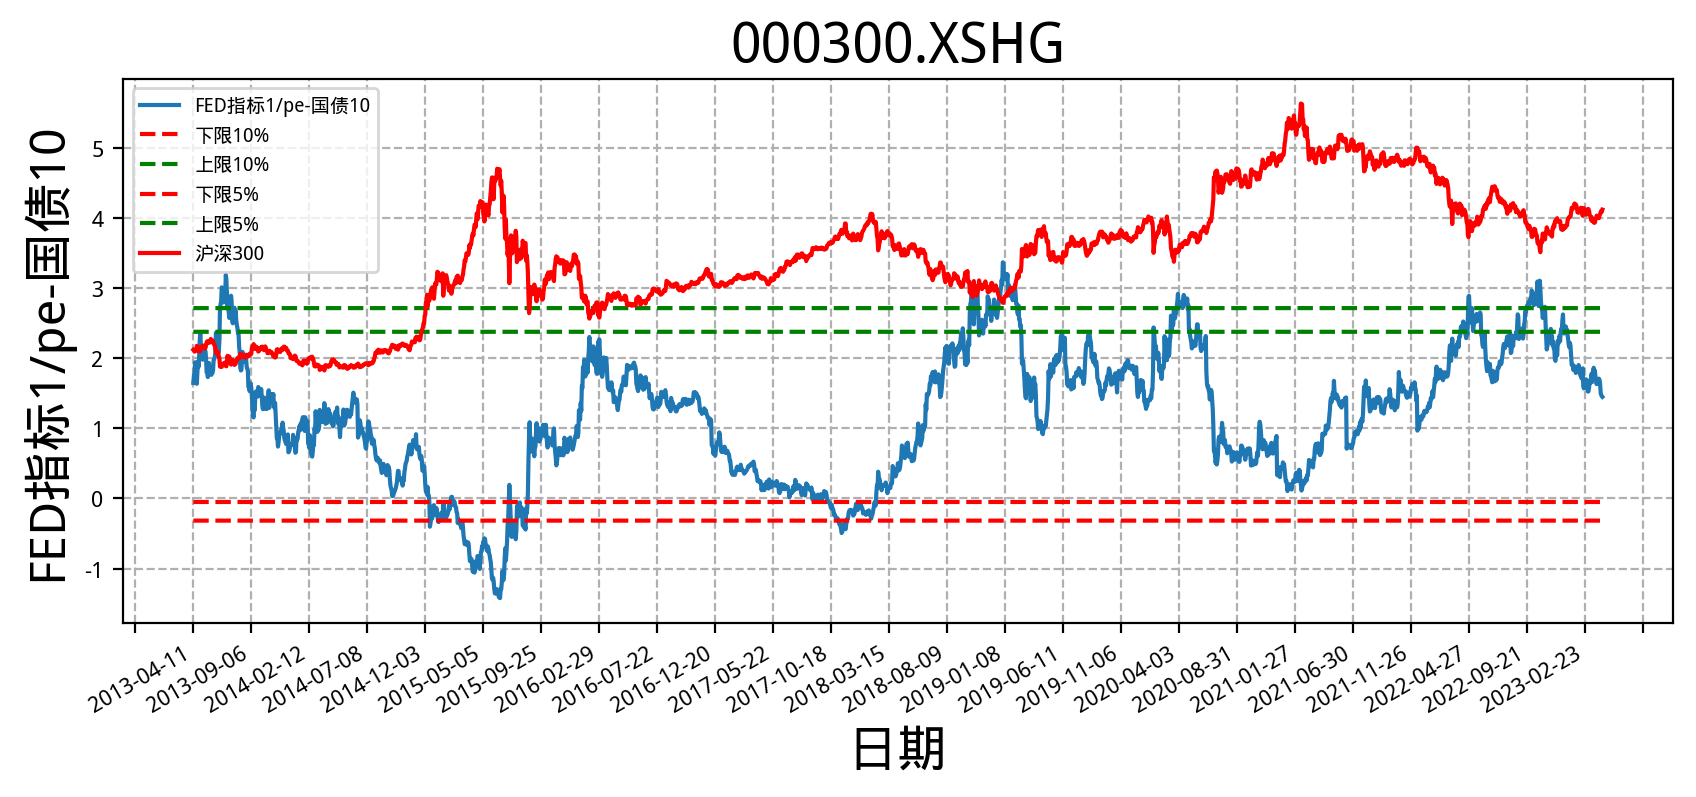

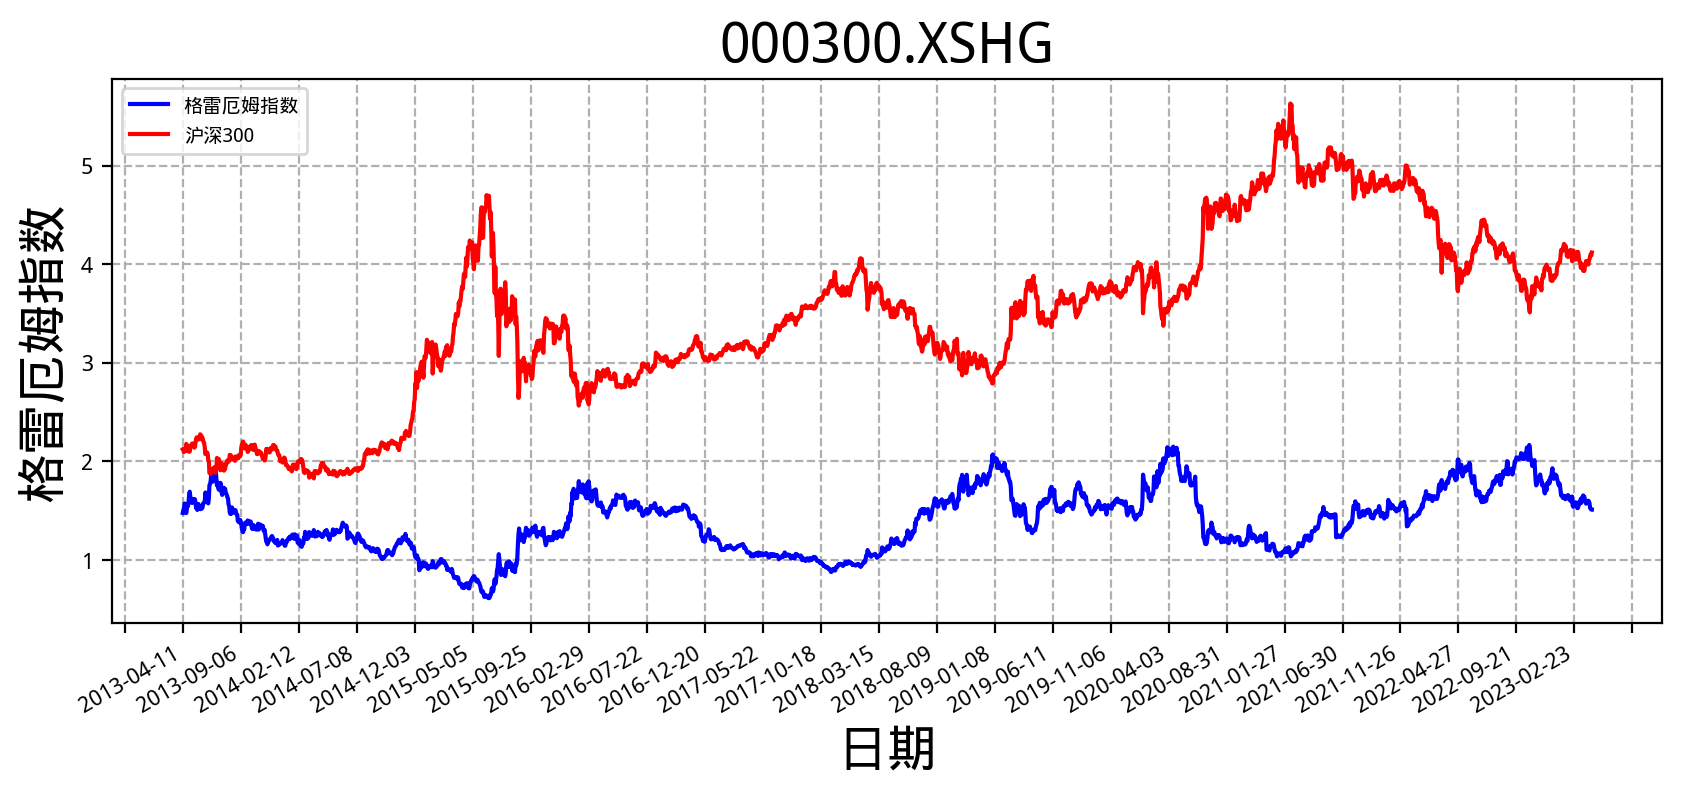

In [12]:
# 0.准备画图

#获取沪深300数据
re=get_price("510300.XSHG", start_date=my_start_time, end_date=my_end_time, frequency='daily', fields=["close"], fq='pre', panel=False)
re=list(re["close"])


#第一张图画FED指标。
#横轴x为日期索引，y轴是指标1/pe-十年国债收益率
x=last_dataframe.index
y=((100/last_dataframe['pe'])-last_dataframe['ten_bond']).values
#上下10/20分位处取极限
pe_list1=np.sort(y)
fw10=int(len(y)/10)
top10=pe_list1[fw10-1]
bottom10=pe_list1[-fw10]
y_down=[top10]*len(y)
y_up=[bottom10]*len(y)

fw20=int(len(y)/20)
top5=pe_list1[fw20-1]
bottom5=pe_list1[-fw20]
y_down2=[top5]*len(y)
y_up2=[bottom5]*len(y)


fig, ax = plt.subplots(figsize=(10,4),dpi=200)

ax.plot(x, y, label="FED指标1/pe-国债10")
ax.plot(x, y_down, color="r", linestyle="--", label="下限10%")
ax.plot(x, y_up, color="g", linestyle="--", label="上限10%")
ax.plot(x, y_down2, color="r", linestyle="--", label="下限5%")
ax.plot(x, y_up2, color="g", linestyle="--", label="上限5%")
ax.plot(re, "red", label="沪深300")

ax.set_title(my_security, fontsize=20)
ax.set_xlabel("日期", fontsize=18)
ax.set_ylabel('FED指标1/pe-国债10', fontsize=18,fontstyle='oblique')
ax.legend()

#在xaxis上通过tick_spacing设置x轴的显示间隔
tick_spacing = 100
ax.xaxis.set_major_locator(ticker.MultipleLocator(tick_spacing))

ax.grid(True, linestyle="--", alpha=1)

fig.autofmt_xdate()  # 自动旋转日期标记

# 设置坐标轴label的大小，背景色等信息
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontsize(8)
    #label.set_bbox(dict(facecolor = 'green', edgecolor = 'None', alpha = 0.2))
plt.legend(loc='upper left',fontsize='x-small')
plt.show()



#画格雷厄姆指数
fig, ax = plt.subplots(figsize=(10,4),dpi=200)

pe_ten_bond = (100/last_dataframe['pe'])/last_dataframe['ten_bond']

ax.plot(x, pe_ten_bond, color="blue", label="格雷厄姆指数")
ax.plot(re, "red", label="沪深300")

ax.set_title(my_security, fontsize=20)
ax.set_xlabel("日期", fontsize=18)
ax.set_ylabel('格雷厄姆指数', fontsize=18,fontstyle='oblique')
ax.legend()

#在xaxis上通过tick_spacing设置x轴的显示间隔
tick_spacing = 100
ax.xaxis.set_major_locator(ticker.MultipleLocator(tick_spacing))

ax.grid(True, linestyle="--", alpha=1)

fig.autofmt_xdate()  # 自动旋转日期标记

# 设置坐标轴label的大小，背景色等信息
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontsize(8)
    #label.set_bbox(dict(facecolor = 'green', edgecolor = 'None', alpha = 0.2))
plt.legend(loc='upper left',fontsize='x-small')
plt.show()